# Week 9 – Day 1 Lab
## Stable Diffusion: Text-to-Image Generation

### Objectives

By the end of this lab, you will:
- Generate images using Stable Diffusion.
- Understand how prompts influence image generation.
- Experiment with inference steps, CFG scale, and random seeds.
- Build a mini AI-generated image gallery.


# Step 1: Enable GPU Runtime

In [1]:
import torch

if torch.cuda.is_available():
    print("✅ GPU is available!")
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("❌ GPU is not available. Please enable GPU from Runtime → Change runtime type.")

✅ GPU is available!
GPU Name: Tesla T4


# Install Libraries

In [2]:
!pip install diffusers transformers accelerate safetensors

# Import Libraries

In [3]:
import torch
from diffusers import StableDiffusionPipeline
from PIL import Image

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


# Load Stable Diffusion Model

In [4]:
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

print("✅ Stable Diffusion model loaded successfully!")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

✅ Stable Diffusion model loaded successfully!


# Generate First Image

  0%|          | 0/50 [00:00<?, ?it/s]

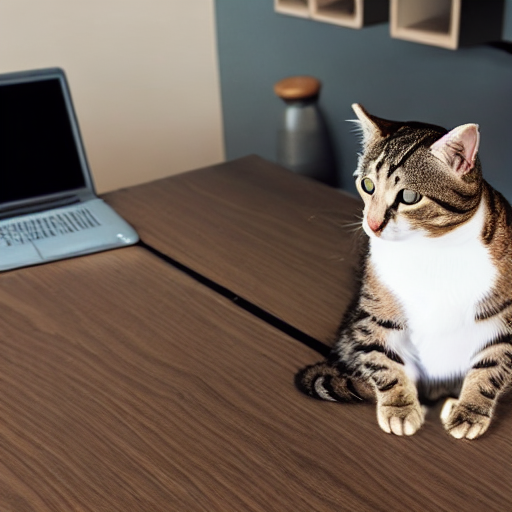

In [8]:
prompt = "A realistic cat sitting on the table in an office"

image = pipe(prompt).images[0]

display(image)

## 2nd Image

  0%|          | 0/50 [00:00<?, ?it/s]

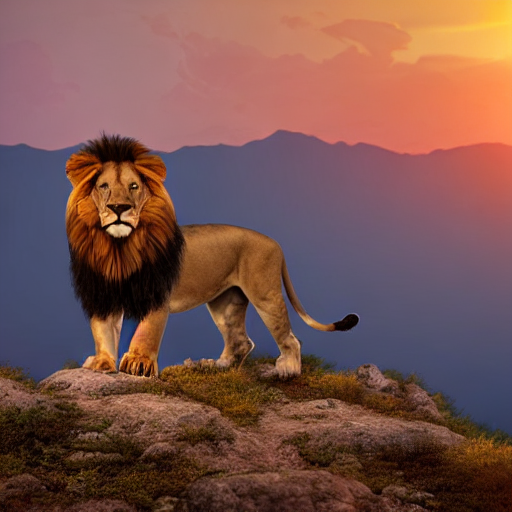

In [10]:
prompt = "A majestic lion standing on a mountain at sunset, cinematic, highly detailed, realistic"

image2 = pipe(prompt).images[0]

display(image2)

# For image Saving

In [9]:
image.save("generated_image.png")

print("✅ Image saved successfully!")

✅ Image saved successfully!


In [11]:
image2.save("generated_image2.png")

print("✅ Image2 saved successfully!")

✅ Image2 saved successfully!


# Img_Generate With Parameters

  0%|          | 0/30 [00:00<?, ?it/s]

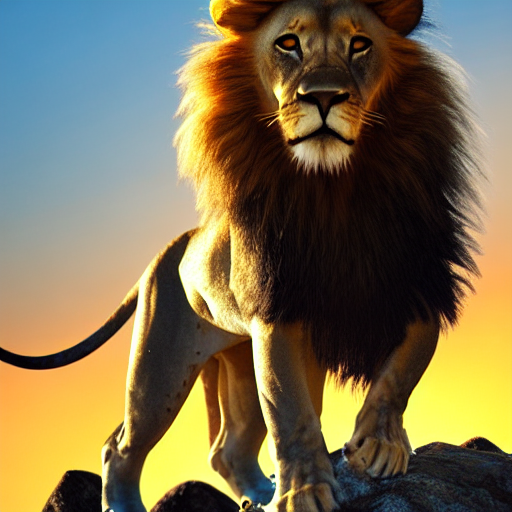

In [14]:
prompt = "A majestic lion standing on a mountain at sunset, cinematic, highly detailed, realistic"

image3 = pipe(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

display(image3)

In [15]:
# Save image
image3.save("generated_image3.png")

print("✅ Image3 saved successfully!")

✅ Image3 saved successfully!


# Experiments

# Experiment 1

  0%|          | 0/50 [00:00<?, ?it/s]

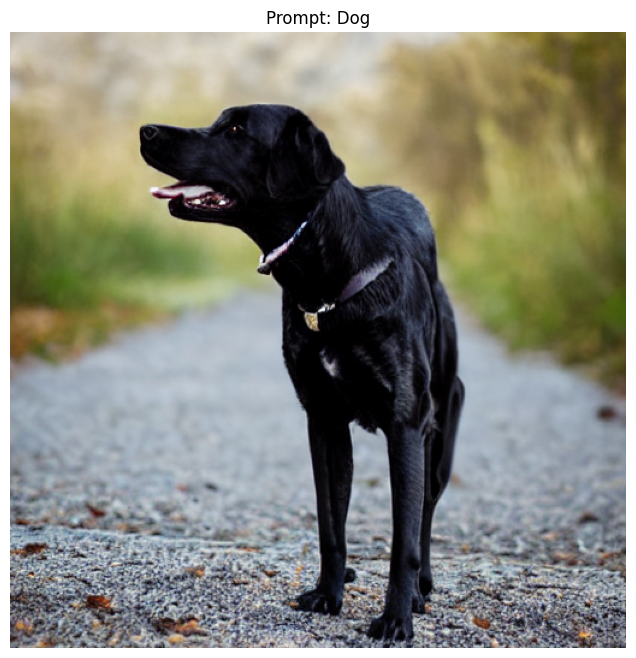

In [19]:
import matplotlib.pyplot as plt
prompt1 = "black Dog"

image_dog = pipe(prompt1).images[0]

plt.figure(figsize=(8, 8))
plt.imshow(image_dog)
plt.axis("off")
plt.title("Prompt: Dog")
plt.show()

# Experiment 2

  0%|          | 0/50 [00:00<?, ?it/s]

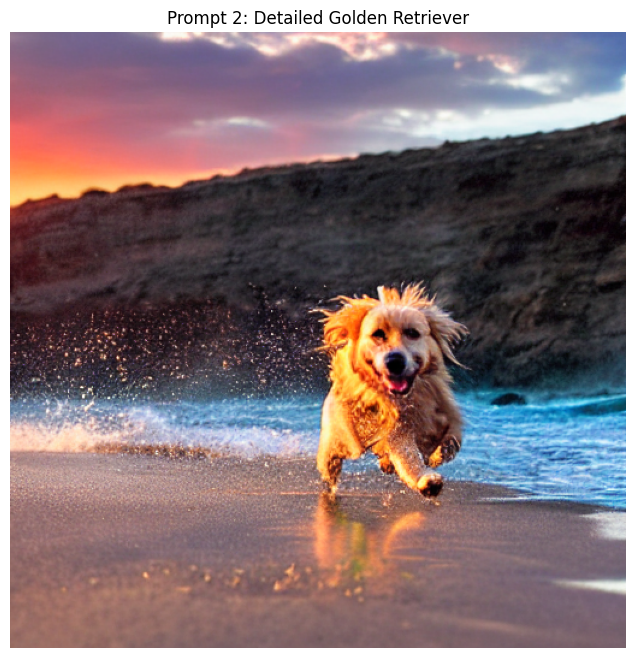

In [21]:
prompt2 = "A golden dog running on a beach during sunset, cinematic lighting, highly detailed, realistic photography"

image2 = pipe(prompt2).images[0]

plt.figure(figsize=(8, 8))
plt.imshow(image2)
plt.axis("off")
plt.title("Prompt 2: Detailed Golden Retriever")
plt.show()

## Reflection
###
 1. The detailed prompt generated the better image.

2. The detailed prompt contained more visual details.

3. Detailed prompts usually produce better results because they give the model more specific information about the subject, environment, lighting, style, and other visual characteristics.

# Experiment 2 Infrence step

## 20-steps

  0%|          | 0/20 [00:00<?, ?it/s]

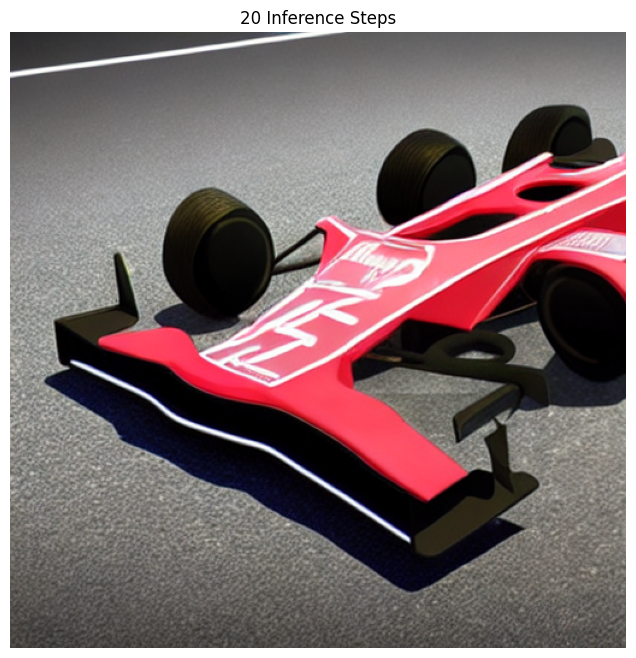

In [24]:
prompt = "A realstic racing car"

image_20 = pipe(
    prompt,
    num_inference_steps=20
).images[0]

plt.figure(figsize=(8, 8))
plt.imshow(image_20)
plt.axis("off")
plt.title("20 Inference Steps")
plt.show()

## 50-steps

  0%|          | 0/50 [00:00<?, ?it/s]

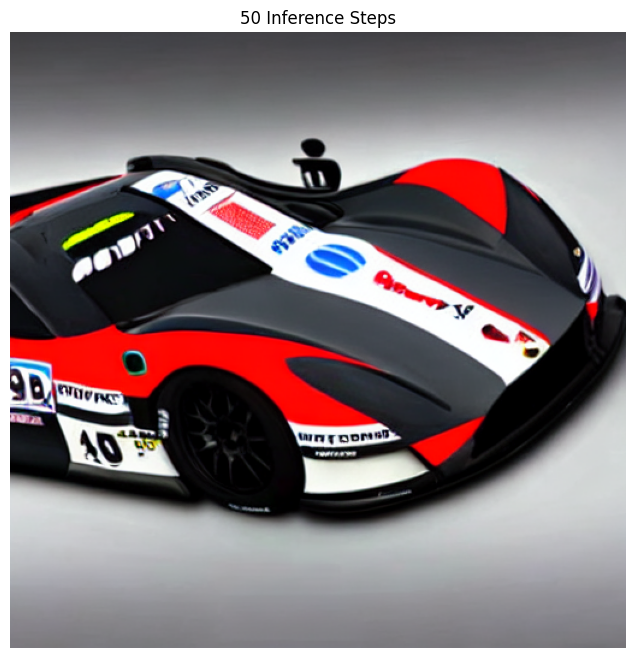

In [25]:
image_50 = pipe(
    prompt,
    num_inference_steps=50
).images[0]

plt.figure(figsize=(8, 8))
plt.imshow(image_50)
plt.axis("off")
plt.title("50 Inference Steps")
plt.show()

## Reflection
###
- The 50-step image generally looks more refined and sharper.

- There can be a noticeable improvement, although the difference may not always be significant.

- Yes, image generation takes longer with 50 inference steps because the model performs more denoising iterations.

# Experiment - 3 Guidene Scale(CFG)

  0%|          | 0/50 [00:00<?, ?it/s]

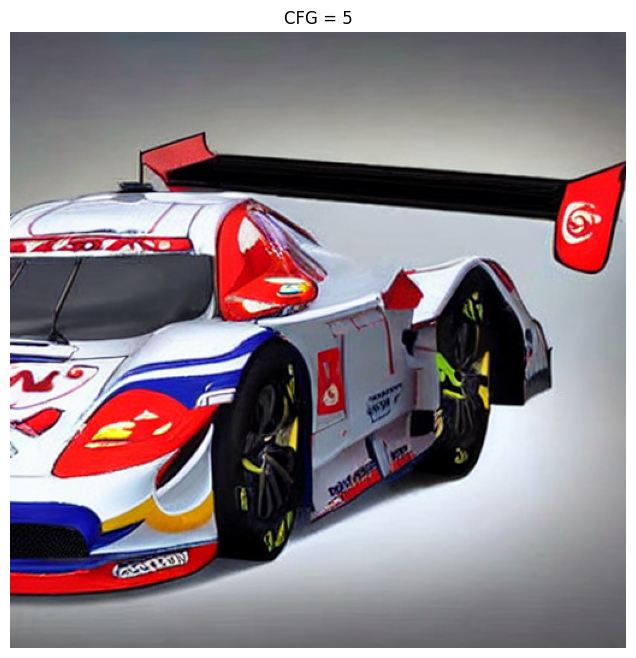

In [27]:
prompt = "A realistic racing car"

image_cfg5 = pipe(
    prompt,
    guidance_scale=5
).images[0]

plt.figure(figsize=(8, 8))
plt.imshow(image_cfg5)
plt.axis("off")
plt.title("CFG = 5")
plt.show()

# CFG =8

  0%|          | 0/50 [00:00<?, ?it/s]

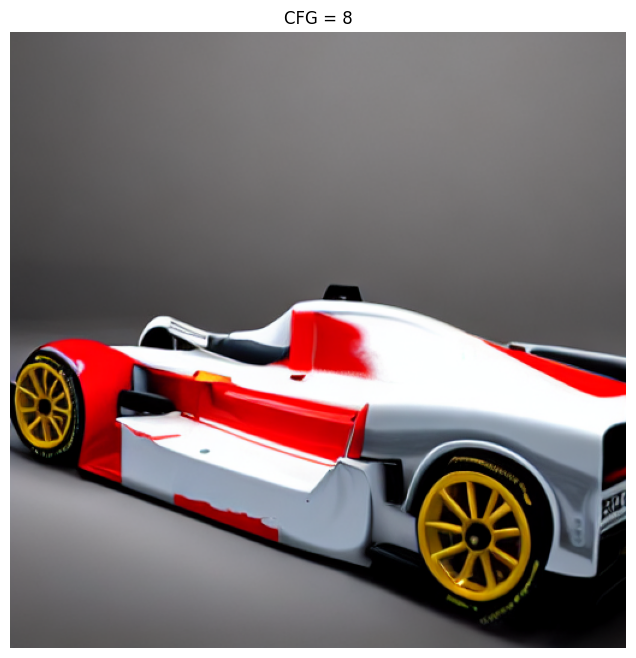

In [28]:
image_cfg8 = pipe(
    prompt,
    guidance_scale=8
).images[0]

plt.figure(figsize=(8, 8))
plt.imshow(image_cfg8)
plt.axis("off")
plt.title("CFG = 8")
plt.show()

# CFG = 12

  0%|          | 0/50 [00:00<?, ?it/s]

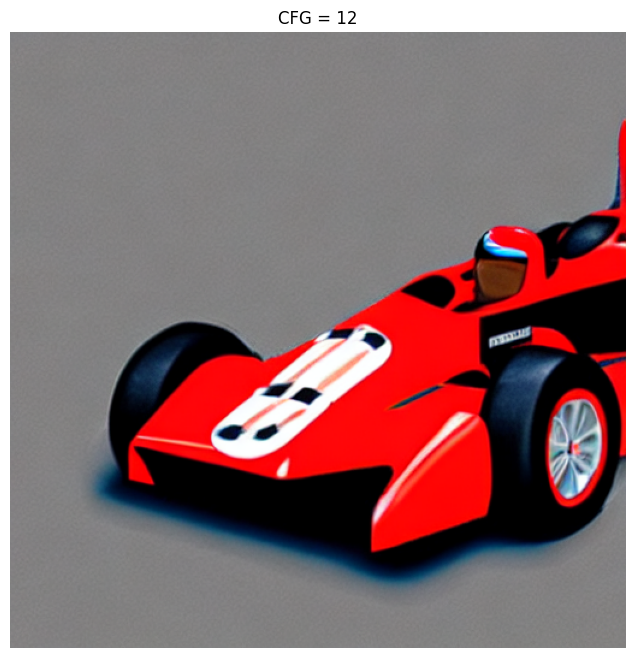

In [29]:
image_cfg12 = pipe(
    prompt,
    guidance_scale=12
).images[0]

plt.figure(figsize=(8, 8))
plt.imshow(image_cfg12)
plt.axis("off")
plt.title("CFG = 12")
plt.show()

# reflection
###
- CFG = 8 generally produced the best balance between prompt accuracy and image quality.

- CFG = 8 generally followed the prompt accurately while maintaining good visual quality.

- When CFG becomes too high, the image can become over-processed, less natural, or contain unwanted visual artifacts.

# Experiment 4

# Seed = 42

  0%|          | 0/50 [00:00<?, ?it/s]

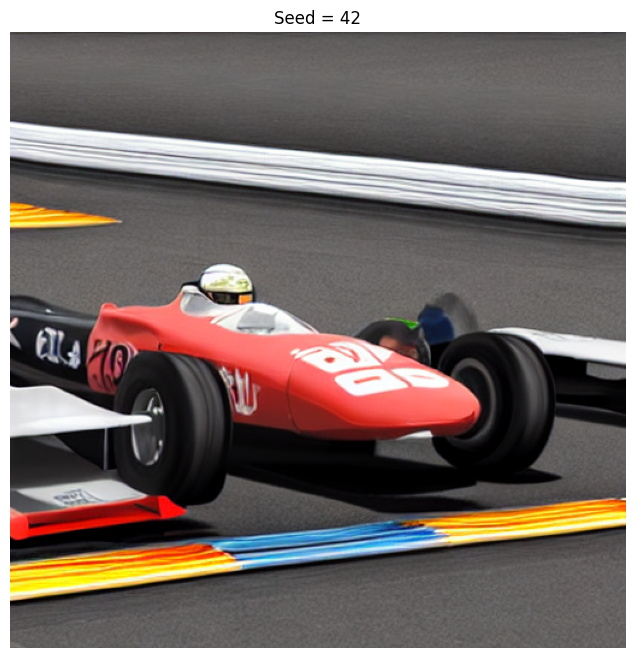

In [32]:
prompt = "A realistic racing car"

generator_42 = torch.Generator("cuda").manual_seed(42)

image_seed42 = pipe(
    prompt,
    generator=generator_42
).images[0]

plt.figure(figsize=(8, 8))
plt.imshow(image_seed42)
plt.axis("off")
plt.title("Seed = 42")
plt.show()

# Seed = 100

  0%|          | 0/50 [00:00<?, ?it/s]

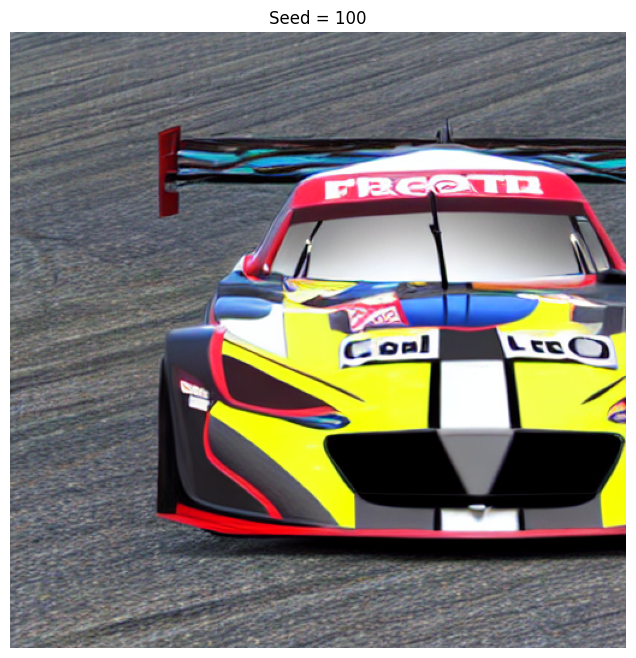

In [33]:
generator_100 = torch.Generator("cuda").manual_seed(100)

image_seed100 = pipe(
    prompt,
    generator=generator_100
).images[0]

plt.figure(figsize=(8, 8))
plt.imshow(image_seed100)
plt.axis("off")
plt.title("Seed = 100")
plt.show()

# Seed = 500

  0%|          | 0/50 [00:00<?, ?it/s]

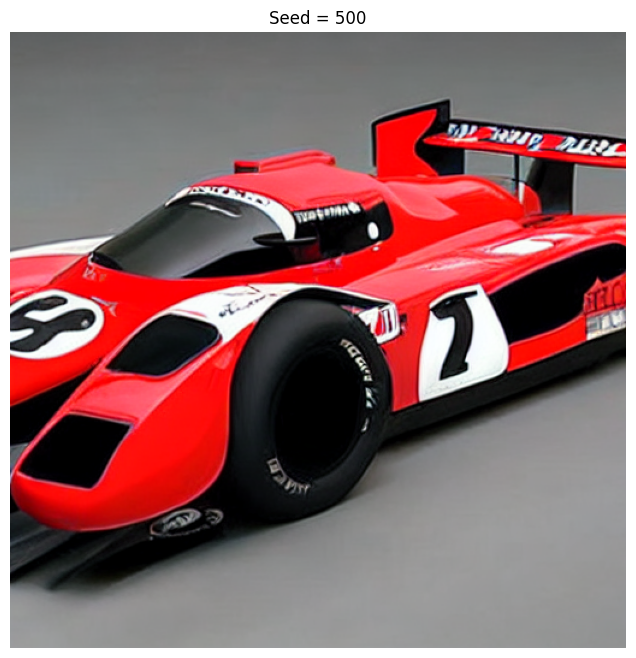

In [34]:
generator_500 = torch.Generator("cuda").manual_seed(500)

image_seed500 = pipe(
    prompt,
    generator=generator_500
).images[0]

plt.figure(figsize=(8, 8))
plt.imshow(image_seed500)
plt.axis("off")
plt.title("Seed = 500")
plt.show()

# reflection
###
- My favorite image was the image generated with seed 42.

- When the seed changed, the initial random noise changed, resulting in a different image composition and visual details.

- Seeds are useful because they allow us to reproduce the same random starting point and generate the same result when the other settings remain unchanged.